Galaxy Shapes with GalSim
=========================

An introduction to common galaxy surface-brightness profiles and how to measure
them from images. We use [GalSim](https://github.com/GalSim-developers/GalSim)
to draw ideal (noise-free, PSF-free) postage stamps, extract 1-D radial profiles,
and fit analytic models.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import galsim

Helpers: radial profile, fit models, and moments
------------------------------------------------


In [3]:
def radial_profile(image, scale, n_bins=40):
    """Azimuthally average a postage stamp about its geometric center.

    Parameters
    ----------
    image : 2-D ndarray
        Pixel values (e.g. from ``galsim.Image.array``).
    scale : float
        Pixel scale in arcsec / pixel.
    n_bins : int
        Number of radial bins.

    Returns
    -------
    r, I : 1-D ndarrays
        Bin-center radii (arcsec) and mean intensity in each bin.
    """
    ny, nx = image.shape
    y, x = np.indices(image.shape)
    # GalSim images are centered on the geometric center of the array
    r_pix = np.sqrt((x - (nx - 1) / 2.0) ** 2 + (y - (ny - 1) / 2.0) ** 2)
    r = r_pix * scale

    r_max = r.max()
    bins = np.linspace(0.0, r_max, n_bins + 1)
    inds = np.digitize(r.ravel(), bins) - 1

    r_cen = 0.5 * (bins[:-1] + bins[1:])
    I = np.array([
        image.ravel()[inds == i].mean() if np.any(inds == i) else np.nan
        for i in range(n_bins)
    ])
    ok = np.isfinite(I)
    return r_cen[ok], I[ok]


def gaussian_1d(r, I0, sigma):
    """Circular Gaussian surface brightness: I(r) = I0 exp(-r^2 / (2 sigma^2))."""
    return I0 * np.exp(-0.5 * (r / sigma) ** 2)


def bn_sersic(n):
    """Ciotti & Bertin (1999) approximation for the Sersic b_n."""
    return 2.0 * n - 1.0 / 3.0 + 4.0 / (405.0 * n) + 46.0 / (25515.0 * n ** 2)


def sersic_1d(r, Ie, Re, n):
    """Circular Sersic profile: I(r) = Ie exp[-b_n ((r/Re)^{1/n} - 1)]."""
    bn = bn_sersic(n)
    return Ie * np.exp(-bn * ((r / Re) ** (1.0 / n) - 1.0))


def moments_to_Q(sigma, e1, e2):
    """Convert adaptive-moment size and distortion (e1, e2) to second moments.

    Uses Q = sigma^2 / sqrt(1 - |e|^2) * [[1+e1, e2], [e2, 1-e1]],
    so det(Q) = sigma^4.

    Returns
    -------
    Qxx, Qyy, Qxy : float
    """
    fac = sigma**2 / np.sqrt(1.0 - e1**2 - e2**2)
    Qxx = fac * (1.0 + e1)
    Qyy = fac * (1.0 - e1)
    Qxy = fac * e2
    return Qxx, Qyy, Qxy


def Q_to_e(Qxx, Qyy, Qxy):
    """Convert second moments to distortion ellipticity (e1, e2)."""
    T = Qxx + Qyy
    e1 = (Qxx - Qyy) / T
    e2 = 2.0 * Qxy / T
    return e1, e2


1. Circular Gaussian galaxy
---------------------------

The Gaussian is the simplest useful galaxy model. GalSim parameterizes it by
flux and $\sigma$ (see Demo 1 in the GalSim tutorials).

$$I(r) = I_0 \, \exp\!\left(-\frac{r^2}{2\sigma^2}\right)$$

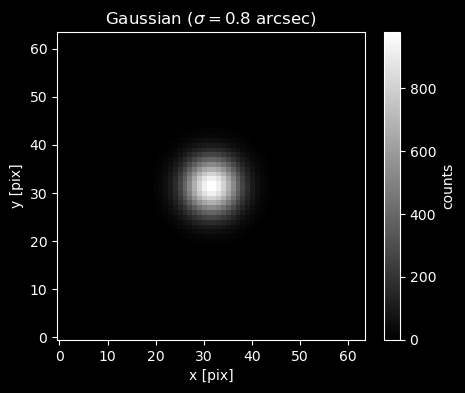

In [4]:
# True parameters (easy to tweak)
flux_g = 1.0e5
sigma_true = 0.8  # arcsec
pixel_scale = 0.2  # arcsec / pixel
nx = 64

gal = galsim.Gaussian(flux=flux_g, sigma=sigma_true)
image_g = gal.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
arr_g = image_g.array

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(arr_g, origin="lower", cmap="gray")
fig.colorbar(im, ax=ax, label="counts")
ax.set_title(rf"Gaussian ($\sigma = {sigma_true}$ arcsec)")
ax.set_xlabel("x [pix]")
ax.set_ylabel("y [pix]")
plt.show()

True  sigma = 0.8000 arcsec
Fit   sigma = 0.7999 arcsec
Fit   I0    = 992.8410


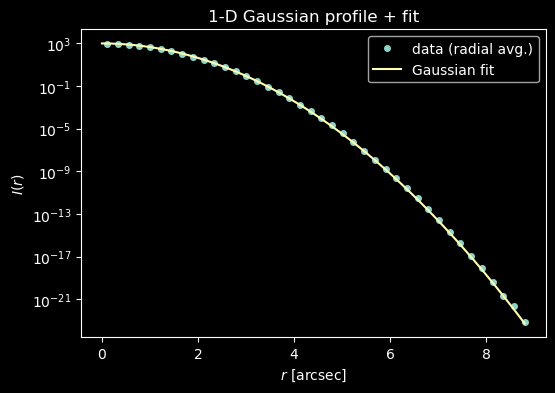

In [5]:
r_g, I_g = radial_profile(arr_g, pixel_scale)

# Fit I0 and sigma from the image radial profile
p0 = [I_g.max(), sigma_true]
popt_g, _ = curve_fit(gaussian_1d, r_g, I_g, p0=p0, bounds=([0, 0], [np.inf, np.inf]))
I0_fit, sigma_fit = popt_g

print(f"True  sigma = {sigma_true:.4f} arcsec")
print(f"Fit   sigma = {sigma_fit:.4f} arcsec")
print(f"Fit   I0    = {I0_fit:.4f}")

r_model = np.linspace(0, r_g.max(), 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_g, I_g, "o", ms=4, label="data (radial avg.)")
ax.plot(r_model, gaussian_1d(r_model, *popt_g), "-", label="Gaussian fit")
ax.set_xlabel(r"$r$ [arcsec]")
ax.set_ylabel(r"$I(r)$")
ax.set_title("1-D Gaussian profile + fit")
ax.legend()
ax.set_yscale("log")
plt.show()

2. Circular Sérsic galaxy (no PSF)
----------------------------------

The Sérsic profile is the workhorse model for galaxy light distributions
(Demo 3). Special cases: $n=1$ is exponential (disk-like), $n=4$ is
de Vaucouleurs (bulge-like).

$$I(r) = I_e \, \exp\!\left[-b_n\left(\left(\frac{r}{R_e}\right)^{1/n} - 1\right)\right]$$

Here $R_e$ is the half-light radius and $b_n$ is chosen so that half the total
flux lies within $R_e$. We draw **without** a PSF.

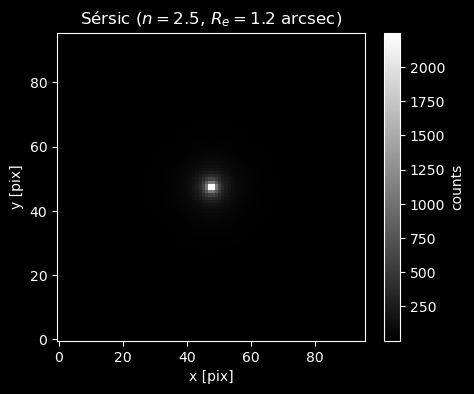

In [6]:
# True parameters
flux_s = 1.0e5
n_true = 2.5
Re_true = 1.2  # arcsec (half-light radius)
pixel_scale = 0.2
nx = 96

gal = galsim.Sersic(n=n_true, half_light_radius=Re_true, flux=flux_s)
image_s = gal.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
arr_s = image_s.array

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(arr_s, origin="lower", cmap="gray")
fig.colorbar(im, ax=ax, label="counts")
ax.set_title(rf"Sérsic ($n = {n_true}$, $R_e = {Re_true}$ arcsec)")
ax.set_xlabel("x [pix]")
ax.set_ylabel("y [pix]")
plt.show()

True  n = 2.5000,  Re = 1.2000 arcsec
Fit   n = 2.2517,  Re = 1.1076 arcsec
Fit   Ie = 177.6116


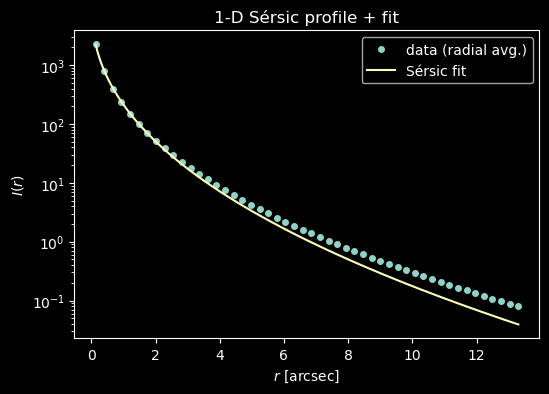

In [7]:
r_s, I_s = radial_profile(arr_s, pixel_scale, n_bins=50)

# Fit Ie, Re, n (with sensible bounds)
p0 = [I_s[np.argmin(np.abs(r_s - Re_true))], Re_true, n_true]
bounds = ([0, 0.05, 0.5], [np.inf, r_s.max(), 6.0])
popt_s, _ = curve_fit(sersic_1d, r_s, I_s, p0=p0, bounds=bounds, maxfev=10000)
Ie_fit, Re_fit, n_fit = popt_s

print(f"True  n = {n_true:.4f},  Re = {Re_true:.4f} arcsec")
print(f"Fit   n = {n_fit:.4f},  Re = {Re_fit:.4f} arcsec")
print(f"Fit   Ie = {Ie_fit:.4f}")

r_model = np.linspace(r_s.min() + 1e-3, r_s.max(), 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_s, I_s, "o", ms=4, label="data (radial avg.)")
ax.plot(r_model, sersic_1d(r_model, *popt_s), "-", label="Sérsic fit")
ax.set_xlabel(r"$r$ [arcsec]")
ax.set_ylabel(r"$I(r)$")
ax.set_title("1-D Sérsic profile + fit")
ax.legend()
ax.set_yscale("log")
plt.show()

3. Elliptical Gaussian and $(g_1, g_2)$
---------------------------------------

Reduced shear (or ellipticity in the same convention) is a complex quantity

$$g = g_1 + i\, g_2 \,,\qquad |g| = \frac{a-b}{a+b} \,,\qquad
\mathrm{PA} = \tfrac{1}{2}\arg(g)\,.$$

- $g_1 > 0$: stretch along the $x$-axis (flatten along $y$)
- $g_2 > 0$: stretch along the $y = x$ diagonal

In GalSim, apply this with ``obj.shear(g1=..., g2=...)`` (Demo 2).

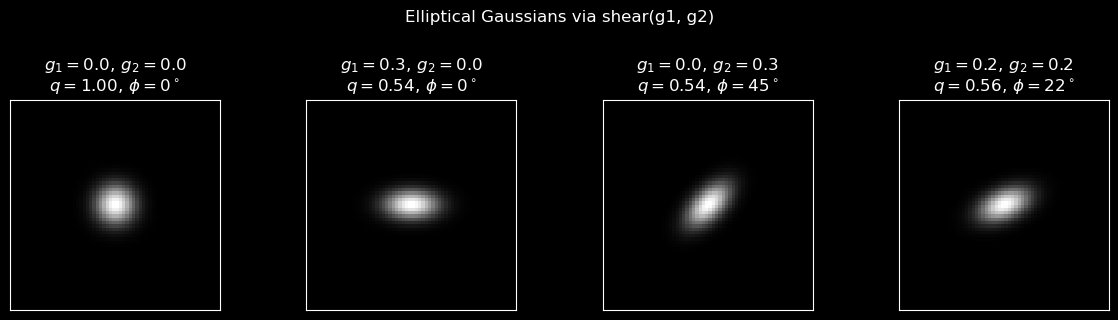

In [8]:
sigma = 0.8
flux = 1.0e5
pixel_scale = 0.2
nx = 64

# (g1, g2) pairs to visualize
shears = [(0.0, 0.0), (0.3, 0.0), (0.0, 0.3), (0.2, 0.2)]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (g1, g2) in zip(axes, shears):
    gal = galsim.Gaussian(flux=flux, sigma=sigma).shear(g1=g1, g2=g2)
    arr = gal.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel").array

    sh = galsim.Shear(g1=g1, g2=g2)
    ax.imshow(arr, origin="lower", cmap="gray")
    ax.set_title(
        rf"$g_1={g1:.1f},\, g_2={g2:.1f}$"
        + "\n"
        + rf"$q={sh.q:.2f},\, \phi={sh.beta.deg:.0f}^\circ$"
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Elliptical Gaussians via shear(g1, g2)", y=1.05)
plt.tight_layout()
plt.show()

4. PSF size and observed ellipticity
------------------------------------

A circular PSF dilutes the apparent shape of an elliptical galaxy: larger PSFs
drive the measured ellipticity toward zero. Here we fix a sheared Gaussian
galaxy and convolve it with circular Gaussian PSFs of increasing size, then
measure the observed shape with GalSim's adaptive moments
(`image.FindAdaptiveMom()`, Demo 1).


True g1, g2 = -0.3, 0.1
True e1, e2 = -0.5455, 0.1818


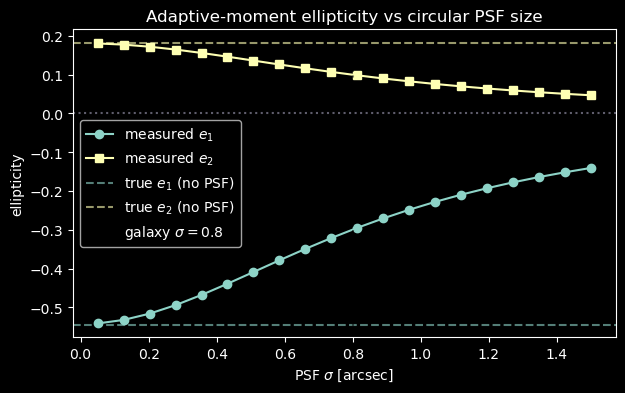

In [9]:
# Fixed elliptical galaxy
gal_sigma = 0.8   # arcsec
g1_true, g2_true = -0.3, 0.1
flux = 1.0e5
pixel_scale = 0.2
nx = 64

gal = galsim.Gaussian(flux=flux, sigma=gal_sigma).shear(g1=g1_true, g2=g2_true)

# Circular Gaussian PSFs spanning unresolved → galaxy-dominated
psf_sigmas = np.linspace(0.05, 1.5, 20)
e1_meas, e2_meas = [], []

for psf_sigma in psf_sigmas:
    psf = galsim.Gaussian(flux=1.0, sigma=psf_sigma)
    obj = galsim.Convolve([gal, psf])
    image = obj.drawImage(nx=nx, ny=nx, scale=pixel_scale)
    mom = image.FindAdaptiveMom()
    e1_meas.append(mom.observed_shape.e1)
    e2_meas.append(mom.observed_shape.e2)

e1_meas = np.array(e1_meas)
e2_meas = np.array(e2_meas)

# Intrinsic (no PSF) ellipticities for reference
e_true = galsim.Shear(g1=g1_true, g2=g2_true)
print(f"True g1, g2 = {g1_true}, {g2_true}")
print(f"True e1, e2 = {e_true.e1:.4f}, {e_true.e2:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(psf_sigmas, e1_meas, "o-", label=r"measured $e_1$")
ax.plot(psf_sigmas, e2_meas, "s-", label=r"measured $e_2$")
ax.axhline(e_true.e1, color="C0", ls="--", alpha=0.6, label=r"true $e_1$ (no PSF)")
ax.axhline(e_true.e2, color="C1", ls="--", alpha=0.6, label=r"true $e_2$ (no PSF)")
ax.axvline(gal_sigma, color="k", ls=":", alpha=0.5, label=rf"galaxy $\sigma={gal_sigma}$")
ax.set_xlabel(r"PSF $\sigma$ [arcsec]")
ax.set_ylabel("ellipticity")
ax.set_title("Adaptive-moment ellipticity vs circular PSF size")
ax.axhline(0.0, color="C2", ls=":", alpha=0.5)
ax.legend()
plt.show()


5. Recovering intrinsic ellipticity by moment subtraction
--------------------------------------------------------

For Gaussians, second moments add under convolution:
$Q_{\mathrm{obs}} = Q_{\mathrm{gal}} + Q_{\mathrm{psf}}$.
Distortion ellipticity is
$$
e_1 = \frac{Q_{xx}-Q_{yy}}{T},\quad
e_2 = \frac{2Q_{xy}}{T},\quad
T = Q_{xx}+Q_{yy}.
$$

Adaptive moments give a size (`moments_sigma`) and $(e_1,e_2)$. We reconstruct
$$
Q = \frac{\sigma^2}{\sqrt{1-e_1^2-e_2^2}}
\begin{pmatrix}1+e_1 & e_2 \\ e_2 & 1-e_1\end{pmatrix}
$$
(so $\det Q = \sigma^4$), subtract the PSF moments,
$Q_{\mathrm{gal}} = Q_{\mathrm{obs}} - Q_{\mathrm{psf}}$, and convert back to $e$.


True e1, e2 = -0.5455, 0.1818
Corrected e1 range: -0.5509 .. -0.5454
Corrected e2 range: 0.1818 .. 0.1836


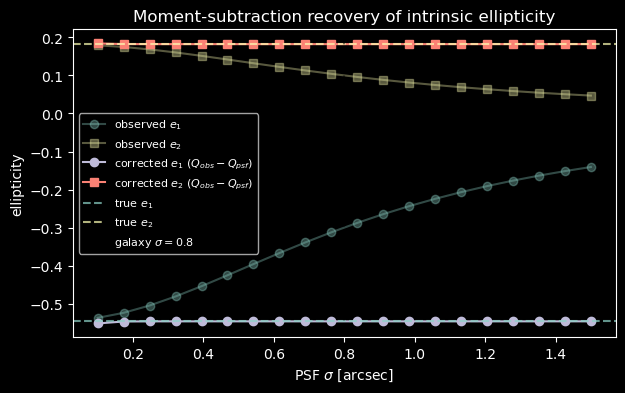

In [10]:
# Same fixed galaxy as Section 4
gal_sigma = 0.8   # arcsec
g1_true, g2_true = -0.3, 0.1
flux = 1.0e5
pixel_scale = 0.2
nx = 64

gal = galsim.Gaussian(flux=flux, sigma=gal_sigma).shear(g1=g1_true, g2=g2_true)
e_true = galsim.Shear(g1=g1_true, g2=g2_true)

psf_sigmas = np.linspace(0.1, 1.5, 20)  # floor 0.1 arcsec so PSF-alone moments converge
e1_obs, e2_obs = [], []
e1_corr, e2_corr = [], []

for psf_sigma in psf_sigmas:
    psf = galsim.Gaussian(flux=1.0, sigma=psf_sigma)
    obs_image = galsim.Convolve([gal, psf]).drawImage(nx=nx, ny=nx, scale=pixel_scale)
    psf_image = psf.drawImage(nx=nx, ny=nx, scale=pixel_scale)

    mom_obs = obs_image.FindAdaptiveMom()
    mom_psf = psf_image.FindAdaptiveMom()

    e1_obs.append(mom_obs.observed_shape.e1)
    e2_obs.append(mom_obs.observed_shape.e2)

    Q_obs = moments_to_Q(
        mom_obs.moments_sigma,
        mom_obs.observed_shape.e1,
        mom_obs.observed_shape.e2,
    )
    Q_psf = moments_to_Q(
        mom_psf.moments_sigma,
        mom_psf.observed_shape.e1,
        mom_psf.observed_shape.e2,
    )
    Q_gal = (Q_obs[0] - Q_psf[0], Q_obs[1] - Q_psf[1], Q_obs[2] - Q_psf[2])
    e1_g, e2_g = Q_to_e(*Q_gal)
    e1_corr.append(e1_g)
    e2_corr.append(e2_g)

e1_obs, e2_obs = np.array(e1_obs), np.array(e2_obs)
e1_corr, e2_corr = np.array(e1_corr), np.array(e2_corr)

print(f"True e1, e2 = {e_true.e1:.4f}, {e_true.e2:.4f}")
print(f"Corrected e1 range: {e1_corr.min():.4f} .. {e1_corr.max():.4f}")
print(f"Corrected e2 range: {e2_corr.min():.4f} .. {e2_corr.max():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(psf_sigmas, e1_obs, "o-", alpha=0.35, label=r"observed $e_1$")
ax.plot(psf_sigmas, e2_obs, "s-", alpha=0.35, label=r"observed $e_2$")
ax.plot(psf_sigmas, e1_corr, "o-", label=r"corrected $e_1$ ($Q_{obs}-Q_{psf}$)")
ax.plot(psf_sigmas, e2_corr, "s-", label=r"corrected $e_2$ ($Q_{obs}-Q_{psf}$)")
ax.axhline(e_true.e1, color="C0", ls="--", alpha=0.7, label=r"true $e_1$")
ax.axhline(e_true.e2, color="C1", ls="--", alpha=0.7, label=r"true $e_2$")
ax.axvline(gal_sigma, color="k", ls=":", alpha=0.5, label=rf"galaxy $\sigma={gal_sigma}$")
ax.set_xlabel(r"PSF $\sigma$ [arcsec]")
ax.set_ylabel("ellipticity")
ax.set_title("Moment-subtraction recovery of intrinsic ellipticity")
ax.legend(fontsize=8)
plt.show()


6. 90-degree galaxy pairs
-------------------------

A standard trick to cancel *shape noise* is to observe galaxies in pairs that
are identical except for a $90^\circ$ rotation. Because ellipticity has period
$\pi$ (not $2\pi$), a $90^\circ$ rotation flips the sign of the intrinsic
shape ($g \to -g$, and likewise $e \to -e$). After applying the **same** shear
$(g_1,g_2)$ and convolving with the **same** PSF, PSF-corrected shapes nearly
cancel their intrinsic parts under averaging, leaving a residual close to the
applied shear (Demo 5).

We report both **reduced shear** $g$ and **distortion** $e$. In the weak limit,
$e \approx 2g$ (exactly $e = 2g/(1+|g|^2)$), so the pair-averaged distortion
should sit near $2g_{\mathrm{lens}}$.


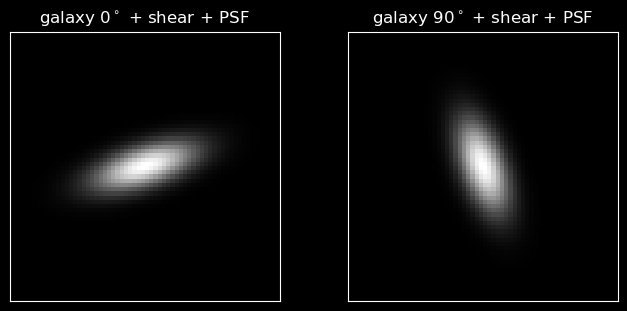

Applied lensing shear:     g1, g2 = 0.0500, 0.0200
  (weak-limit 2g):       2g1, 2g2 = 0.1000, 0.0400
Galaxy 0 deg:              g1, g2 = 0.4407, 0.3089
                           e1, e2 = 0.6835, 0.4790
Galaxy 90 deg:             g1, g2 = -0.3573, -0.2900
                           e1, e2 = -0.5897, -0.4787
Pair average:              g1, g2 = 0.0417, 0.0094
                           e1, e2 = 0.0833, 0.0188


In [31]:
# Intrinsic galaxy (before lensing shear) and its 90-degree partner
gal_sigma = 0.9  # arcsec
e_int_g1, e_int_g2 = 0.4, 0.3  # large intrinsic shape (as reduced shear g)
flux = 1.0e5
pixel_scale = 0.2
nx = 64

# Applied lensing shear (same for both) and circular PSF (same for both)
g1_lens, g2_lens = 0.05, 0.02
psf_sigma = 0.4  # arcsec

gal0 = galsim.Gaussian(flux=flux, sigma=gal_sigma).shear(g1=e_int_g1, g2=e_int_g2)
gal90 = gal0.rotate(90 * galsim.degrees)
psf = galsim.Gaussian(flux=1.0, sigma=psf_sigma)

# Shear both, then convolve with the PSF
obs0 = galsim.Convolve([gal0.shear(g1=g1_lens, g2=g2_lens), psf])
obs90 = galsim.Convolve([gal90.shear(g1=g1_lens, g2=g2_lens), psf])

image0 = obs0.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
image90 = obs90.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
psf_image = psf.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(image0.array, origin="lower", cmap="gray")
axes[0].set_title(r"galaxy $0^\circ$ + shear + PSF")
axes[1].imshow(image90.array, origin="lower", cmap="gray")
axes[1].set_title(r"galaxy $90^\circ$ + shear + PSF")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


def intrinsic_shape_from_image(image, psf_image):
    """PSF-corrected shape as a galsim.Shear (access .g1/.g2 or .e1/.e2)."""
    mom_obs = image.FindAdaptiveMom()
    mom_psf = psf_image.FindAdaptiveMom()
    Q_obs = moments_to_Q(
        mom_obs.moments_sigma,
        mom_obs.observed_shape.e1,
        mom_obs.observed_shape.e2,
    )
    Q_psf = moments_to_Q(
        mom_psf.moments_sigma,
        mom_psf.observed_shape.e1,
        mom_psf.observed_shape.e2,
    )
    Q_gal = (Q_obs[0] - Q_psf[0], Q_obs[1] - Q_psf[1], Q_obs[2] - Q_psf[2])
    e1, e2 = Q_to_e(*Q_gal)
    return galsim.Shear(e1=e1, e2=e2)


def pair_averaged_shape(gal0, psf, g1_lens, g2_lens, shape_from_image=None,
                        nx=64, pixel_scale=0.2):
    """Apply shear+PSF to a galaxy and its 90-deg partner; return mean as Shear.

    shape_from_image(image, psf_image) must return a galsim.Shear.
    Defaults to intrinsic_shape_from_image (moment subtraction).
    """
    if shape_from_image is None:
        shape_from_image = intrinsic_shape_from_image
    gal90 = gal0.rotate(90 * galsim.degrees)
    obs0 = galsim.Convolve([gal0.shear(g1=g1_lens, g2=g2_lens), psf])
    obs90 = galsim.Convolve([gal90.shear(g1=g1_lens, g2=g2_lens), psf])
    image0 = obs0.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
    image90 = obs90.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
    psf_image = psf.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")
    sh0 = shape_from_image(image0, psf_image)
    sh90 = shape_from_image(image90, psf_image)
    g1_avg = 0.5 * (sh0.g1 + sh90.g1)
    g2_avg = 0.5 * (sh0.g2 + sh90.g2)
    return galsim.Shear(g1=g1_avg, g2=g2_avg)


sh0 = intrinsic_shape_from_image(image0, psf_image)
sh90 = intrinsic_shape_from_image(image90, psf_image)
g_avg = pair_averaged_shape(
    gal0, psf, g1_lens, g2_lens, nx=nx, pixel_scale=pixel_scale
)

print(f"Applied lensing shear:     g1, g2 = {g1_lens:.4f}, {g2_lens:.4f}")
print(f"  (weak-limit 2g):       2g1, 2g2 = {2*g1_lens:.4f}, {2*g2_lens:.4f}")
print(f"Galaxy 0 deg:              g1, g2 = {sh0.g1:.4f}, {sh0.g2:.4f}")
print(f"                           e1, e2 = {sh0.e1:.4f}, {sh0.e2:.4f}")
print(f"Galaxy 90 deg:             g1, g2 = {sh90.g1:.4f}, {sh90.g2:.4f}")
print(f"                           e1, e2 = {sh90.e1:.4f}, {sh90.e2:.4f}")
print(f"Pair average:              g1, g2 = {g_avg.g1:.4f}, {g_avg.g2:.4f}")
print(f"                           e1, e2 = {g_avg.e1:.4f}, {g_avg.e2:.4f}")


HSM `EstimateShear` PSF correction
----------------------------------

The moment-subtraction above is exact for Gaussian $\otimes$ Gaussian. GalSim's
HSM routine `galsim.hsm.EstimateShear` (default `REGAUSS`) is the more general
moments-based PSF correction used in practice (Demo 2). It returns a
PSF-corrected distortion; we wrap that as a `galsim.Shear`.


In [32]:
def hsm_shape_from_image(image, psf_image, sky_var=0.0):
    """PSF-corrected shape via galsim.hsm.EstimateShear, as a galsim.Shear."""
    res = galsim.hsm.EstimateShear(image, psf_image, sky_var=sky_var)
    # Default REGAUSS reports corrected distortion (e); g fields may be unused.
    return galsim.Shear(e1=res.corrected_e1, e2=res.corrected_e2)


sh0_hsm = hsm_shape_from_image(image0, psf_image)
sh90_hsm = hsm_shape_from_image(image90, psf_image)
g_avg_hsm = pair_averaged_shape(
    gal0, psf, g1_lens, g2_lens,
    shape_from_image=hsm_shape_from_image,
    nx=nx, pixel_scale=pixel_scale,
)

print(f"Applied lensing shear:     g1, g2 = {g1_lens:.4f}, {g2_lens:.4f}")
print(f"  (weak-limit 2g):       2g1, 2g2 = {2*g1_lens:.4f}, {2*g2_lens:.4f}")
print(f"HSM galaxy 0 deg:          g1, g2 = {sh0_hsm.g1:.4f}, {sh0_hsm.g2:.4f}")
print(f"                           e1, e2 = {sh0_hsm.e1:.4f}, {sh0_hsm.e2:.4f}")
print(f"HSM galaxy 90 deg:         g1, g2 = {sh90_hsm.g1:.4f}, {sh90_hsm.g2:.4f}")
print(f"                           e1, e2 = {sh90_hsm.e1:.4f}, {sh90_hsm.e2:.4f}")
print(f"HSM pair average:          g1, g2 = {g_avg_hsm.g1:.4f}, {g_avg_hsm.g2:.4f}")
print(f"                           e1, e2 = {g_avg_hsm.e1:.4f}, {g_avg_hsm.e2:.4f}")
print(f"Moment-sub pair average:   g1, g2 = {g_avg.g1:.4f}, {g_avg.g2:.4f}")
print(f"                           e1, e2 = {g_avg.e1:.4f}, {g_avg.e2:.4f}")


Applied lensing shear:     g1, g2 = 0.0500, 0.0200
  (weak-limit 2g):       2g1, 2g2 = 0.1000, 0.0400
HSM galaxy 0 deg:          g1, g2 = 0.4407, 0.3089
                           e1, e2 = 0.6835, 0.4790
HSM galaxy 90 deg:         g1, g2 = -0.3573, -0.2900
                           e1, e2 = -0.5897, -0.4787
HSM pair average:          g1, g2 = 0.0417, 0.0094
                           e1, e2 = 0.0833, 0.0188
Moment-sub pair average:   g1, g2 = 0.0417, 0.0094
                           e1, e2 = 0.0833, 0.0188


Same exercise with HSM (cf. Section 5)
--------------------------------------

Repeat the PSF-size sweep from Section 5, but correct with
`hsm_shape_from_image` / `EstimateShear` instead of subtracting second moments.


True e1, e2 = -0.5455, 0.1818
HSM-corrected e1 range: -0.5455 .. -0.5452
HSM-corrected e2 range: 0.1818 .. 0.1818


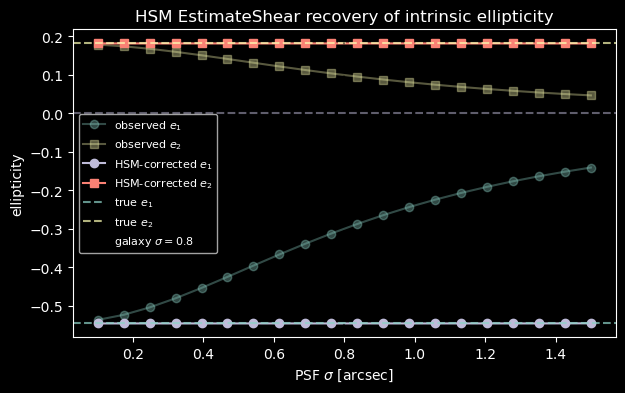

In [34]:
# Same fixed galaxy as Section 4 / 5
gal_sigma = 0.8   # arcsec
g1_true, g2_true = -0.3, 0.1
flux = 1.0e5
pixel_scale = 0.2
nx = 64

gal = galsim.Gaussian(flux=flux, sigma=gal_sigma).shear(g1=g1_true, g2=g2_true)
e_true = galsim.Shear(g1=g1_true, g2=g2_true)

psf_sigmas = np.linspace(0.1, 1.5, 20)
e1_obs, e2_obs = [], []
e1_corr, e2_corr = [], []

for psf_sigma in psf_sigmas:
    psf = galsim.Gaussian(flux=1.0, sigma=psf_sigma)
    obs_image = galsim.Convolve([gal, psf]).drawImage(nx=nx, ny=nx, scale=pixel_scale)
    psf_image = psf.drawImage(nx=nx, ny=nx, scale=pixel_scale)

    mom_obs = obs_image.FindAdaptiveMom()
    e1_obs.append(mom_obs.observed_shape.e1)
    e2_obs.append(mom_obs.observed_shape.e2)

    sh_corr = hsm_shape_from_image(obs_image, psf_image)
    e1_corr.append(sh_corr.e1)
    e2_corr.append(sh_corr.e2)

e1_obs, e2_obs = np.array(e1_obs), np.array(e2_obs)
e1_corr, e2_corr = np.array(e1_corr), np.array(e2_corr)

print(f"True e1, e2 = {e_true.e1:.4f}, {e_true.e2:.4f}")
print(f"HSM-corrected e1 range: {e1_corr.min():.4f} .. {e1_corr.max():.4f}")
print(f"HSM-corrected e2 range: {e2_corr.min():.4f} .. {e2_corr.max():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(psf_sigmas, e1_obs, "o-", alpha=0.35, label=r"observed $e_1$")
ax.plot(psf_sigmas, e2_obs, "s-", alpha=0.35, label=r"observed $e_2$")
ax.plot(psf_sigmas, e1_corr, "o-", label=r"HSM-corrected $e_1$")
ax.plot(psf_sigmas, e2_corr, "s-", label=r"HSM-corrected $e_2$")
ax.axhline(e_true.e1, color="C0", ls="--", alpha=0.7, label=r"true $e_1$")
ax.axhline(e_true.e2, color="C1", ls="--", alpha=0.7, label=r"true $e_2$")
ax.axhline(0.0, color="C2", ls="--", alpha=0.5)
ax.axvline(gal_sigma, color="k", ls=":", alpha=0.5, label=rf"galaxy $\sigma={gal_sigma}$")
ax.set_xlabel(r"PSF $\sigma$ [arcsec]")
ax.set_ylabel("ellipticity")
ax.set_title(r"HSM EstimateShear recovery of intrinsic ellipticity")
ax.legend(fontsize=8)
plt.show()


Sweeping $g_1$ with a fixed $g_2$
---------------------------------

Reuse the same intrinsic pair and PSF. Vary the applied $g_1$ from $-0.1$ to
$0.1$ at fixed $g_2$. Plot residuals for the pair-averaged reduced shear
($\langle g\rangle - g_{\mathrm{true}}$) and distortion
($\langle e\rangle - 2g_{\mathrm{true}}$), since $e\approx 2g$ in the weak limit.


In [ ]:
g1_true_grid = np.linspace(-0.1, 0.1, 21)
g2_fixed = g2_lens  # keep g2 from the previous cell

g1_rec, g2_rec = [], []
e1_rec, e2_rec = [], []
for g1_true in g1_true_grid:
    sh_m = pair_averaged_shape(
        gal0, psf, g1_true, g2_fixed, nx=nx, pixel_scale=pixel_scale
    )
    g1_rec.append(sh_m.g1)
    g2_rec.append(sh_m.g2)
    e1_rec.append(sh_m.e1)
    e2_rec.append(sh_m.e2)

g1_rec, g2_rec = np.array(g1_rec), np.array(g2_rec)
e1_rec, e2_rec = np.array(e1_rec), np.array(e2_rec)

dg1 = g1_rec - g1_true_grid
dg2 = g2_rec - g2_fixed
de1 = e1_rec - 2.0 * g1_true_grid
de2 = e2_rec - 2.0 * g2_fixed

# Linear fit: residual ≈ slope * g1_true + intercept
m_g1, c_g1 = np.polyfit(g1_true_grid, dg1, 1)
m_g2, c_g2 = np.polyfit(g1_true_grid, dg2, 1)
m_e1, c_e1 = np.polyfit(g1_true_grid, de1, 1)
m_e2, c_e2 = np.polyfit(g1_true_grid, de2, 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(g1_true_grid, dg1, "o-", label="data")
axes[0, 0].plot(g1_true_grid, m_g1 * g1_true_grid + c_g1, "-",
                label=rf"fit: slope$={m_g1:.3f}$, $c={c_g1:.4f}$")
axes[0, 0].axhline(0.0, color="k", ls="--", alpha=0.5)
axes[0, 0].set_xlabel(r"true $g_1$")
axes[0, 0].set_ylabel(r"recovered $g_1$ $-$ true $g_1$")
axes[0, 0].set_title(r"$g_1$ residual")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(g1_true_grid, dg2, "s-", label="data")
axes[0, 1].plot(g1_true_grid, m_g2 * g1_true_grid + c_g2, "-",
                label=rf"fit: slope$={m_g2:.3f}$, $c={c_g2:.4f}$")
axes[0, 1].axhline(0.0, color="k", ls="--", alpha=0.5)
axes[0, 1].set_xlabel(r"true $g_1$")
axes[0, 1].set_ylabel(r"recovered $g_2$ $-$ true $g_2$")
axes[0, 1].set_title(r"$g_2$ residual")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(g1_true_grid, de1, "o-", label="data")
axes[1, 0].plot(g1_true_grid, m_e1 * g1_true_grid + c_e1, "-",
                label=rf"fit: slope$={m_e1:.3f}$, $c={c_e1:.4f}$")
axes[1, 0].axhline(0.0, color="k", ls="--", alpha=0.5)
axes[1, 0].set_xlabel(r"true $g_1$")
axes[1, 0].set_ylabel(r"recovered $e_1$ $-$ $2\times$true $g_1$")
axes[1, 0].set_title(r"$e_1$ residual vs $2g_1$")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(g1_true_grid, de2, "s-", label="data")
axes[1, 1].plot(g1_true_grid, m_e2 * g1_true_grid + c_e2, "-",
                label=rf"fit: slope$={m_e2:.3f}$, $c={c_e2:.4f}$")
axes[1, 1].axhline(0.0, color="k", ls="--", alpha=0.5)
axes[1, 1].set_xlabel(r"true $g_1$")
axes[1, 1].set_ylabel(r"recovered $e_2$ $-$ $2\times$true $g_2$")
axes[1, 1].set_title(r"$e_2$ residual vs $2g_2$")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"g1 residual fit:  slope (m) = {m_g1:.4f},  intercept (c) = {c_g1:.4f}")
print(f"g2 residual fit:  slope (m) = {m_g2:.4f},  intercept (c) = {c_g2:.4f}")
print(f"e1 residual fit:  slope (m) = {m_e1:.4f},  intercept (c) = {c_e1:.4f}")
print(f"e2 residual fit:  slope (m) = {m_e2:.4f},  intercept (c) = {c_e2:.4f}")
print(f"max |g1_rec - g1_true|     = {np.max(np.abs(dg1)):.4f}")
print(f"max |g2_rec - g2_fixed|    = {np.max(np.abs(dg2)):.4f}")
print(f"max |e1_rec - 2 g1_true|   = {np.max(np.abs(de1)):.4f}")
print(f"max |e2_rec - 2 g2_fixed|  = {np.max(np.abs(de2)):.4f}")


Why is there still a bias?
--------------------------

The residual $\langle g\rangle - g_{\mathrm{true}}$ (and
$\langle e\rangle - 2g_{\mathrm{true}}$) is *not* from noise, pixelation
(we used `method="no_pixel"`), or PSF dilution. For Gaussian galaxies and a
Gaussian PSF, moment subtraction recovers each object's shear-induced shape
essentially exactly.

In the weak limit, distortion and reduced shear are related by $e\approx 2g$
(exactly $e = 2g/(1+|g|^2)$), which is why the pair-averaged $e$ tracks
$2g_{\mathrm{lens}}$.

The bias itself comes from **nonlinear shear composition**. Reduced shear does
not add linearly: if a galaxy has intrinsic reduced shear $g^{\mathrm{int}}$
and the lens applies $g$, the observed value is
$$
g^{\mathrm{obs}} = \frac{g^{\mathrm{int}} + g}{1 + g^{\mathrm{int}\,*} g}
$$
(complex notation), not $g^{\mathrm{int}} + g$. The same nonlinearity appears
in $e$.

A $90^\circ$ rotation sends $g^{\mathrm{int}} \to -g^{\mathrm{int}}$, so the
pair average cancels the *linear* piece of the intrinsic shape. Higher-order
terms such as $\mathcal{O}\!\left(|g^{\mathrm{int}}|^2 g\right)$ survive, so
$$
\frac{1}{2}\left[g^{\mathrm{obs}}(g^{\mathrm{int}}) + g^{\mathrm{obs}}(-g^{\mathrm{int}})\right]
\neq g
$$
whenever $|g^{\mathrm{int}}|$ is not tiny. That is what the residual plots show:
a small but systematic offset that grows with the intrinsic ellipticity of the
pair (here $|g^{\mathrm{int}}|\sim 0.4\text{--}0.5$), even in this ideal
noiseless Gaussian setup.

In the weak-lensing limit $|g|\ll 1$ and with a realistic ensemble of
intrinsic shapes, one calibrates this with a **shear responsivity** (or
similar weight); a single loud 90-degree pair is not an unbiased $g$
estimator by itself.


7. Noisy pairs at fixed $S/N$
-----------------------------

Simulate `Npair` galaxy pairs (each member is a $90^\circ$ rotation of the other),
apply the same lensing shear and PSF, and add Gaussian noise so each image has
$S/N = 50$ (GalSim `addNoiseSNR`, matched-filter definition). Measure each
galaxy with `EstimateShear`, store the catalog in a NumPy structured array
(recarray), then compare the mean ellipticity to the true shear.


In [1]:
Npair = 100
snr_target = 50.0
rng = galsim.BaseDeviate(12345)
ud = galsim.UniformDeviate(rng)

# Reuse galaxy size / intrinsic |shape| / shear / PSF from Section 6
# (re-run that cell first). Randomize each pair's overall orientation.
dtype = [
    ("pair_id", "i4"),
    ("member", "i4"),       # 0 or 1 (90-deg partner)
    ("g1_lens", "f8"),
    ("g2_lens", "f8"),
    ("e1", "f8"),
    ("e2", "f8"),
    ("g1", "f8"),
    ("g2", "f8"),
    ("snr", "f8"),
    ("sky_var", "f8"),
    ("success", "i4"),
]
catalog = np.zeros(2 * Npair, dtype=dtype)

psf_image = psf.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")

row = 0
for pair_id in range(Npair):
    # Random orientation of the intrinsic pair
    theta = ud() * 2.0 * np.pi * galsim.radians
    gal_a = gal0.rotate(theta)
    gal_b = gal_a.rotate(90 * galsim.degrees)

    for member, gal in enumerate((gal_a, gal_b)):
        obj = galsim.Convolve([gal.shear(g1=g1_lens, g2=g2_lens), psf])
        image = obj.drawImage(nx=nx, ny=nx, scale=pixel_scale, method="no_pixel")

        noise = galsim.GaussianNoise(rng)
        sky_var = image.addNoiseSNR(noise, snr=snr_target, preserve_flux=True)

        catalog[row]["pair_id"] = pair_id
        catalog[row]["member"] = member
        catalog[row]["g1_lens"] = g1_lens
        catalog[row]["g2_lens"] = g2_lens
        catalog[row]["snr"] = snr_target
        catalog[row]["sky_var"] = sky_var

        try:
            sh = hsm_shape_from_image(image, psf_image, sky_var=sky_var)
            catalog[row]["e1"] = sh.e1
            catalog[row]["e2"] = sh.e2
            catalog[row]["g1"] = sh.g1
            catalog[row]["g2"] = sh.g2
            catalog[row]["success"] = 1
        except Exception:
            catalog[row]["e1"] = np.nan
            catalog[row]["e2"] = np.nan
            catalog[row]["g1"] = np.nan
            catalog[row]["g2"] = np.nan
            catalog[row]["success"] = 0
        row += 1

# Optional on-disk copy (NumPy .npy preserves the structured dtype)
catalog_path = "galaxy_pair_catalog_snr50.npy"
np.save(catalog_path, catalog)
print(f"Wrote {catalog_path} with {len(catalog)} rows "
      f"({catalog['success'].sum()} successful measurements)")

# Mean ellipticity over successful measurements
ok = catalog["success"] == 1
e1_mean = np.nanmean(catalog["e1"][ok])
e2_mean = np.nanmean(catalog["e2"][ok])
g1_mean = np.nanmean(catalog["g1"][ok])
g2_mean = np.nanmean(catalog["g2"][ok])

print(f"True lensing shear:     g1, g2 = {g1_lens:.4f}, {g2_lens:.4f}")
print(f"  (weak-limit 2g):    2g1, 2g2 = {2*g1_lens:.4f}, {2*g2_lens:.4f}")
print(f"Mean HSM ellipticity:   e1, e2 = {e1_mean:.4f}, {e2_mean:.4f}")
print(f"Mean HSM reduced shear: g1, g2 = {g1_mean:.4f}, {g2_mean:.4f}")
print(f"<e> - 2g_true:                 = {e1_mean - 2*g1_lens:.4f}, {e2_mean - 2*g2_lens:.4f}")
print(f"<g> - g_true:                  = {g1_mean - g1_lens:.4f}, {g2_mean - g2_lens:.4f}")

# Quick view of the catalog columns
print("columns:", catalog.dtype.names)
print(catalog[:4])


Wrote galaxy_pair_catalog_snr50.npy with 200 rows (200 successful measurements)
True lensing shear:     g1, g2 = 0.0500, 0.0200
  (weak-limit 2g):    2g1, 2g2 = 0.1000, 0.0400
Mean HSM ellipticity:   e1, e2 = 0.0687, 0.0285
Mean HSM reduced shear: g1, g2 = 0.0497, 0.0198
<e> - 2g_true:                 = -0.0313, -0.0115
<g> - g_true:                  = -0.0003, -0.0002
columns: ('pair_id', 'member', 'g1_lens', 'g2_lens', 'e1', 'e2', 'g1', 'g2', 'snr', 'sky_var', 'success')
[(0, 0, 0.05, 0.02,  0.10556971, -0.74597448,  0.06369006, -0.45004539, 50., 12115.15680403, 1)
 (0, 1, 0.05, 0.02,  0.04831454,  0.83431631,  0.03118748,  0.53855878, 50., 11988.59722704, 1)
 (1, 0, 0.05, 0.02,  0.36429927,  0.76022339,  0.23687955,  0.49432263, 50., 11929.7240079 , 1)
 (1, 1, 0.05, 0.02, -0.13731302, -0.78682637, -0.08572926, -0.49124288, 50., 12176.83771569, 1)]


Notes
-----

- Circular radial averaging is appropriate for the round profiles above; once
  the galaxy is elliptical, isophotes are ellipses and a circular average mixes
  different radii along the major/minor axes.
- A circular PSF reduces $|e|$ without changing the position angle much.
- For Gaussian $\otimes$ Gaussian, subtracting second moments recovers the
  intrinsic ellipticity nearly exactly. `galsim.hsm.EstimateShear` does the same
  across PSF size in this Gaussian case, and is the more general tool when
  profiles differ.
- Averaging a $90^\circ$-rotated pair cancels most of the intrinsic shape,
  isolating the common applied shear. Pair-averaged $g$ tracks $g_{\mathrm{lens}}$;
  pair-averaged $e$ tracks $\approx 2g_{\mathrm{lens}}$.
- With noise, use `addNoiseSNR` for a target $S/N$ and pass the resulting
  variance to `EstimateShear` as `sky_var`. A structured NumPy catalog makes it
  easy to stack many pairs and compare $\langle e\rangle$ or $\langle g\rangle$
  to the true shear.
